<a href="https://colab.research.google.com/github/Suman-Poola/Random-Forrest-s-p500/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from fastai import *
import pandas as pd
from google.colab import userdata
import os
import zipfile
import numpy as np

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

import kaggle


In [12]:
dataset_id = 'darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily'
path = 'ticker_list'
kaggle.api.dataset_download_cli(dataset_id, path = str(path), unzip=True, force=True)


Dataset URL: https://www.kaggle.com/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily
License(s): CC0-1.0


100%|██████████| 99.9M/99.9M [00:00<00:00, 239MB/s]


In [13]:
!ls {path}

sp500_companies.csv  sp500_stocks.csv


In [14]:
tk = pd.read_csv('ticker_list/sp500_companies.csv')
tk.head()

,symbol,company,sector,sub_industry,headquarters,date_added,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1989


In [15]:
import numpy as np
tickers = tk['symbol'].tolist()
tickers[0:25]

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE']

In [16]:
len(tickers)

503

In [17]:
tickers[499:503]

['YUM', 'ZBRA', 'ZBH', 'ZTS']

In [18]:
import yfinance as yf
df = yf.download(tickers, period="36mo")
df.head()

/tmp/ipykernel_819/2136594173.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, period="36mo")
[*********************100%***********************]  503 of 503 completed


Price            Close                                                 \
Ticker               A        AAPL        ABBV        ABNB        ABT   
Date                                                                    
2023-08-22  114.983871  174.864929  133.651230  127.080002  98.782753   
2023-08-23  116.440201  178.703003  132.605392  128.130005  98.763977   
2023-08-24  116.792084  174.026276  132.199661  124.720001  97.467537   
2023-08-25  116.977798  176.226501  132.253738  125.790001  97.899673   
2023-08-28  117.212387  177.785446  132.920929  126.154999  96.565666   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2023-08-22  70.908501  292.468719  519.479980  168.299377  73.060760  ...   
2023-08-23  71.697754  298.566193  530.710022  169.080521  73.386406  ...   
2023-08-24  71.707260  297.430023  512.429993  165.469894  72.662773  ...   
2023-08-25  70.956047  301.804291  525.059998  169.728348  73.115044  ...   
2023-08-28  70.547165  303.839905  529.919983  171.795670  73.151215  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2023-08-22  4728200  2296400  3142600  10518800   833700  10494000  1207700   
2023-08-23  3083400  1298600  8610700  11435600  1012500  12207300  1441600   
2023-08-24  1858400  1494000  5780900  10818500   896800   7952700  1131100   
2023-08-25  2768500  1706200  7705600  13579300   973800   7741000  1097300   
2023-08-28  1360500  1209800  3982200  10382100   803600   5333600  1815600   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2023-08-22  3648900  340500  1286400  
2023-08-23  2755200  314800  1022900  
2023-08-24  1953000  246300  1210300  
2023-08-25  1456700  337300   879700  
2023-08-28  2658500  211000  1546900  

[5 rows x 2515 columns]

In [19]:
df.head()

Price            Close                                                 \
Ticker               A        AAPL        ABBV        ABNB        ABT   
Date                                                                    
2023-08-22  114.983871  174.864929  133.651230  127.080002  98.782753   
2023-08-23  116.440201  178.703003  132.605392  128.130005  98.763977   
2023-08-24  116.792084  174.026276  132.199661  124.720001  97.467537   
2023-08-25  116.977798  176.226501  132.253738  125.790001  97.899673   
2023-08-28  117.212387  177.785446  132.920929  126.154999  96.565666   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2023-08-22  70.908501  292.468719  519.479980  168.299377  73.060760  ...   
2023-08-23  71.697754  298.566193  530.710022  169.080521  73.386406  ...   
2023-08-24  71.707260  297.430023  512.429993  165.469894  72.662773  ...   
2023-08-25  70.956047  301.804291  525.059998  169.728348  73.115044  ...   
2023-08-28  70.547165  303.839905  529.919983  171.795670  73.151215  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2023-08-22  4728200  2296400  3142600  10518800   833700  10494000  1207700   
2023-08-23  3083400  1298600  8610700  11435600  1012500  12207300  1441600   
2023-08-24  1858400  1494000  5780900  10818500   896800   7952700  1131100   
2023-08-25  2768500  1706200  7705600  13579300   973800   7741000  1097300   
2023-08-28  1360500  1209800  3982200  10382100   803600   5333600  1815600   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2023-08-22  3648900  340500  1286400  
2023-08-23  2755200  314800  1022900  
2023-08-24  1953000  246300  1210300  
2023-08-25  1456700  337300   879700  
2023-08-28  2658500  211000  1546900  

[5 rows x 2515 columns]

In [20]:
closes = df["Close"]
returns = closes.pct_change() *100

cs = closes.stack().rename("Close")
rs = returns.stack().rename("Returns")
fdf = pd.concat([cs,rs], axis = 1).reset_index()

fdf.columns = ['date', 'ticker', 'close', 'return']
fdf = fdf.dropna(subset=['return'])

fdf.head(25)



/tmp/ipykernel_819/2048977385.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = closes.pct_change() *100


,date,ticker,close,return
495,2023-08-23,A,116.440201,1.266551
496,2023-08-23,AAPL,178.703003,2.194879
497,2023-08-23,ABBV,132.605392,-0.782512
498,2023-08-23,ABNB,128.130005,0.826254
499,2023-08-23,ABT,98.763977,-0.019007
500,2023-08-23,ACGL,71.697754,1.113059
501,2023-08-23,ACN,298.566193,2.084829
502,2023-08-23,ADBE,530.710022,2.161785
503,2023-08-23,ADI,169.080521,0.464139
504,2023-08-23,ADM,73.386406,0.445719


fdf.sort_values(by=['ticker', 'date'], inplace=True)
fdf.head(25)

In [21]:
fdf.sort_values(['ticker', 'date'], inplace=True)
fdf.head(25)

,date,ticker,close,return
495,2023-08-23,A,116.440201,1.266551
990,2023-08-24,A,116.792084,0.302201
1485,2023-08-25,A,116.977798,0.159013
1980,2023-08-28,A,117.212387,0.200541
2475,2023-08-29,A,119.264954,1.751152
2970,2023-08-30,A,119.910072,0.540912
3465,2023-08-31,A,118.336411,-1.312368
3960,2023-09-01,A,119.157471,0.693836
4455,2023-09-05,A,116.049255,-2.608494
4950,2023-09-06,A,115.277092,-0.665376


In [22]:
fdf_appl = fdf[fdf['ticker'] == 'AAPL'].copy()
fdf_appl.head()

,date,ticker,close,return
496,2023-08-23,AAPL,178.703003,2.194879
991,2023-08-24,AAPL,174.026276,-2.617039
1486,2023-08-25,AAPL,176.226501,1.264307
1981,2023-08-28,AAPL,177.785446,0.884626
2476,2023-08-29,AAPL,181.662979,2.181018


In [23]:
len(fdf_appl)

752

In [24]:
fdf_appl['Lag 1'] = fdf_appl['close'].shift(1)
fdf_appl['Lag 2'] = fdf_appl['close'].shift(2)
fdf_appl['Lag 3'] = fdf_appl['close'].shift(3)
fdf_appl['Lag 5'] = fdf_appl['close'].shift(5)
fdf_appl.head(25)

,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5
496,2023-08-23,AAPL,178.703003,2.194879,NaN,NaN,NaN,NaN
991,2023-08-24,AAPL,174.026276,-2.617039,178.703003,NaN,NaN,NaN
1486,2023-08-25,AAPL,176.226501,1.264307,174.026276,178.703003,NaN,NaN
1981,2023-08-28,AAPL,177.785446,0.884626,176.226501,174.026276,178.703003,NaN
2476,2023-08-29,AAPL,181.662979,2.181018,177.785446,176.226501,174.026276,NaN
2971,2023-08-30,AAPL,185.145859,1.917220,181.662979,177.785446,176.226501,178.703003
3466,2023-08-31,AAPL,185.362930,0.117244,185.145859,181.662979,177.785446,174.026276
3961,2023-09-01,AAPL,186.931717,0.846332,185.362930,185.145859,181.662979,176.226501
4456,2023-09-05,AAPL,187.168518,0.126678,186.931717,185.362930,185.145859,177.785446
4951,2023-09-06,AAPL,180.469147,-3.579326,187.168518,186.931717,185.362930,181.662979


In [25]:
fdf['Lag 1'] = fdf.groupby('ticker')['close'].shift(1)
fdf['Lag 2'] = fdf.groupby('ticker')['close'].shift(2)
fdf['Lag 3'] = fdf.groupby('ticker')['close'].shift(3)
fdf['Lag 5'] = fdf.groupby('ticker')['close'].shift(5)
fdf.head(25)

,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5
495,2023-08-23,A,116.440201,1.266551,NaN,NaN,NaN,NaN
990,2023-08-24,A,116.792084,0.302201,116.440201,NaN,NaN,NaN
1485,2023-08-25,A,116.977798,0.159013,116.792084,116.440201,NaN,NaN
1980,2023-08-28,A,117.212387,0.200541,116.977798,116.792084,116.440201,NaN
2475,2023-08-29,A,119.264954,1.751152,117.212387,116.977798,116.792084,NaN
2970,2023-08-30,A,119.910072,0.540912,119.264954,117.212387,116.977798,116.440201
3465,2023-08-31,A,118.336411,-1.312368,119.910072,119.264954,117.212387,116.792084
3960,2023-09-01,A,119.157471,0.693836,118.336411,119.910072,119.264954,116.977798
4455,2023-09-05,A,116.049255,-2.608494,119.157471,118.336411,119.910072,117.212387
4950,2023-09-06,A,115.277092,-0.665376,116.049255,119.157471,118.336411,119.264954


In [26]:
fdf_appl['SMA 5'] = fdf_appl['close'].rolling(window=5).mean()
fdf_appl['SMA 10'] = fdf_appl['close'].rolling(window=10).mean()
fdf_appl['SMA 20'] = fdf_appl['close'].rolling(window=20).mean()
fdf_appl['SMA 30'] = fdf_appl['close'].rolling(window=30).mean()
fdf_appl['SMA 50'] = fdf_appl['close'].rolling(window=50).mean()

fdf_appl.head(100)
#fdf_appl = fdf[fdf['ticker'] == 'AAPL'].copy()
#fdf_appl.head()

,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5,SMA 5,SMA 10,SMA 20,SMA 30,SMA 50
496,2023-08-23,AAPL,178.703003,2.194879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
991,2023-08-24,AAPL,174.026276,-2.617039,178.703003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1486,2023-08-25,AAPL,176.226501,1.264307,174.026276,178.703003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,2023-08-28,AAPL,177.785446,0.884626,176.226501,174.026276,178.703003,NaN,NaN,NaN,NaN,NaN,NaN
2476,2023-08-29,AAPL,181.662979,2.181018,177.785446,176.226501,174.026276,NaN,177.680841,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
47587,2024-01-09,AAPL,182.910034,-0.226337,183.324966,178.997711,179.718948,183.404007,181.396484,185.339413,189.364342,189.337011,185.741104
48083,2024-01-10,AAPL,183.947357,0.567122,182.910034,183.324966,178.997711,182.030762,181.779803,184.661674,189.019051,189.218455,186.100547
48579,2024-01-11,AAPL,183.354614,-0.322235,183.947357,182.910034,183.324966,179.718948,182.506937,183.914781,188.568543,189.060052,186.407289
49075,2024-01-12,AAPL,183.680649,0.177816,183.354614,183.947357,182.910034,178.997711,183.443524,183.158008,187.973795,188.946438,186.711080


In [27]:
fdf_appl['volatility 5'] = fdf_appl['return'].rolling(5).std()
fdf_appl['volatility 10'] = fdf_appl['return'].rolling(10).std()
fdf_appl['volatility 20'] = fdf_appl['return'].rolling(20).std()
fdf_appl['volatility 30'] = fdf_appl['return'].rolling(30).std()
fdf_appl.head()

,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5,SMA 5,SMA 10,SMA 20,SMA 30,SMA 50,volatility 5,volatility 10,volatility 20,volatility 30
496,2023-08-23,AAPL,178.703003,2.194879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
991,2023-08-24,AAPL,174.026276,-2.617039,178.703003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1486,2023-08-25,AAPL,176.226501,1.264307,174.026276,178.703003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,2023-08-28,AAPL,177.785446,0.884626,176.226501,174.026276,178.703003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2476,2023-08-29,AAPL,181.662979,2.181018,177.785446,176.226501,174.026276,NaN,177.680841,NaN,NaN,NaN,NaN,1.98432,NaN,NaN,NaN


In [28]:
fdf_appl = fdf_appl.dropna()
#fdf_appl = fdf_appl.drop(columns = 'SMA 100')
fdf_appl.head()


,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5,SMA 5,SMA 10,SMA 20,SMA 30,SMA 50,volatility 5,volatility 10,volatility 20,volatility 30
24771,2023-11-01,AAPL,171.648438,1.873878,168.491119,168.017517,165.975174,168.816742,167.759030,169.312030,172.510280,171.867802,174.296025,1.673395,1.324774,1.092400,1.082177
25267,2023-11-02,AAPL,175.200378,2.069312,171.648438,168.491119,168.017517,164.662903,169.866525,169.520212,172.641502,171.987516,174.225972,0.742192,1.489238,1.176678,1.134112
25763,2023-11-03,AAPL,174.292648,-0.518110,175.200378,171.648438,168.491119,165.975174,171.530020,169.892180,172.600061,172.048689,174.231300,1.093138,1.403534,1.136202,1.136273
26259,2023-11-06,AAPL,176.838257,1.460537,174.292648,175.200378,171.648438,168.017517,173.294168,170.506866,172.611902,172.152288,174.243535,1.110623,1.454435,1.168666,1.158974
26755,2023-11-07,AAPL,179.393692,1.445069,176.838257,174.292648,175.200378,168.491119,175.474683,171.333687,172.781113,172.476570,174.275700,1.032931,1.492702,1.207874,1.092174


In [29]:
len(fdf_appl)

703

In [30]:
fdf_appl['future return'] = fdf_appl.groupby('ticker')['return'].shift(-1)
fdf_appl = fdf_appl.dropna()
print(len(fdf_appl))
fdf_appl.head(len(fdf_appl))


702


,date,ticker,close,return,Lag 1,Lag 2,Lag 3,Lag 5,SMA 5,SMA 10,SMA 20,SMA 30,SMA 50,volatility 5,volatility 10,volatility 20,volatility 30,future return
24771,2023-11-01,AAPL,171.648438,1.873878,168.491119,168.017517,165.975174,168.816742,167.759030,169.312030,172.510280,171.867802,174.296025,1.673395,1.324774,1.092400,1.082177,2.069312
25267,2023-11-02,AAPL,175.200378,2.069312,171.648438,168.491119,168.017517,164.662903,169.866525,169.520212,172.641502,171.987516,174.225972,0.742192,1.489238,1.176678,1.134112,-0.518110
25763,2023-11-03,AAPL,174.292648,-0.518110,175.200378,171.648438,168.491119,165.975174,171.530020,169.892180,172.600061,172.048689,174.231300,1.093138,1.403534,1.136202,1.136273,1.460537
26259,2023-11-06,AAPL,176.838257,1.460537,174.292648,175.200378,171.648438,168.017517,173.294168,170.506866,172.611902,172.152288,174.243535,1.110623,1.454435,1.168666,1.158974,1.445069
26755,2023-11-07,AAPL,179.393692,1.445069,176.838257,174.292648,175.200378,168.491119,175.474683,171.333687,172.781113,172.476570,174.275700,1.032931,1.492702,1.207874,1.092174,0.588479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372950,2026-08-14,AAPL,305.929993,0.219479,305.260010,302.250000,304.910004,313.059998,305.322003,307.481482,318.219887,318.552157,308.950681,1.036325,1.194857,2.144831,1.989030,-0.111135
373453,2026-08-17,AAPL,305.589996,-0.111135,305.929993,305.260010,302.250000,308.260010,304.788000,307.724625,317.183958,318.325470,308.843245,0.843827,1.038062,2.106093,1.973547,1.452928
373956,2026-08-18,AAPL,310.029999,1.452928,305.589996,305.929993,305.260010,304.910004,305.812000,307.816284,316.312579,318.313393,308.902341,0.916060,0.943478,2.138330,1.989058,2.193332
374459,2026-08-19,AAPL,316.829987,2.193332,310.029999,305.589996,305.929993,302.250000,308.727997,308.426080,315.873619,318.437061,309.213337,0.930132,1.162220,2.204919,2.022921,-1.745415


In [31]:
features = ['close', 'return', 'Lag 1', 'Lag 2', 'Lag 3', 'Lag 5', 'volatility 5', 'volatility 10', 'volatility 20', 'volatility 30','SMA 10' ,'SMA 20','SMA 30','SMA 50']
x = fdf_appl[features]
y = fdf_appl['future return']



In [32]:
split_index = int(0.8 * len(fdf_appl))

x_train, x_test = x.iloc[:split_index], x.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [33]:
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth = 5, random_state=72)

tree.fit(x_train, y_train)
predictions = tree.predict(x_test)

score = mean_squared_error(y_test, predictions)
score


6.649898423148109

In [34]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(n_estimators = 500, random_state=72)
#Change the estimators and max_depth
forest.fit(x_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=72)

In [35]:
predictions = forest.predict(x_test)
score = mean_squared_error(y_test, predictions)
score

3.607059037224508

In [36]:
mean_absolute_error = np.mean((np.abs(y_test - predictions)))

25 3.471316660963767
Loss of index:  1 is: 16.00790465419334
Loss of index:  9 is: 23.551187423173733
Loss of index:  10 is: 37.03143046508616
Loss of index:  63 is: 11.572160920226109
Loss of index:  84 is: 11.219957830249166
Loss of index:  89 is: 16.585005151002065
Loss of index:  100 is: 35.716715587591416
Loss of index:  105 is: 17.235187560001233
Loss of index:  113 is: 17.867412593654617
Loss of index:  120 is: 10.546507111385107
Loss of index:  125 is: 54.43704363394835
50 3.368680525582206
Loss of index:  1 is: 14.880867012772693
Loss of index:  9 is: 26.322274245961864
Loss of index:  10 is: 36.097609412484516
Loss of index:  19 is: 11.578333180849341
Loss of index:  89 is: 15.260594148726943
Loss of index:  100 is: 39.06772686668177
Loss of index:  105 is: 10.29094036522555
Loss of index:  113 is: 14.58866612975271
Loss of index:  125 is: 53.91497102605824
100 3.4578470163518933
Loss of index:  1 is: 15.67132158850383
Loss of index:  9 is: 24.5385887643126
Loss of index:  10

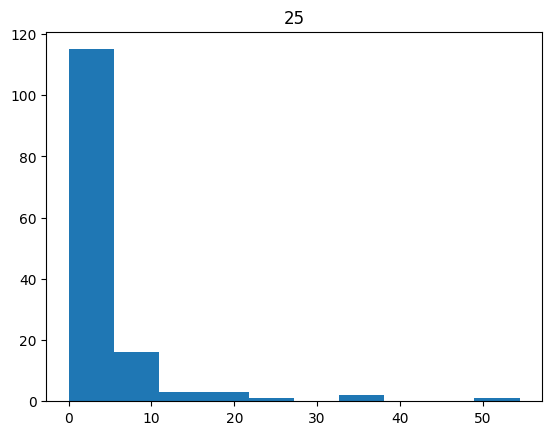

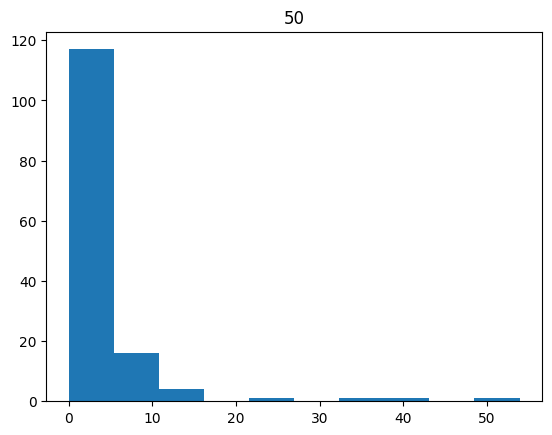

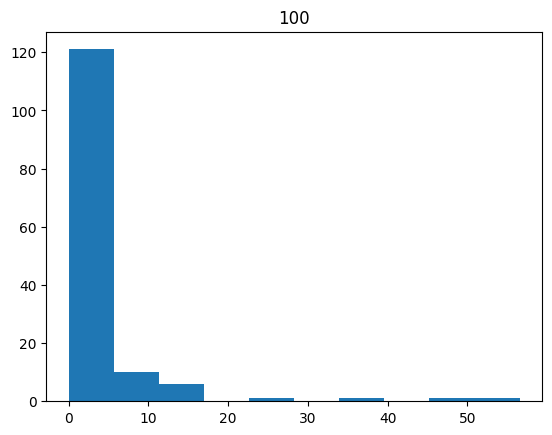

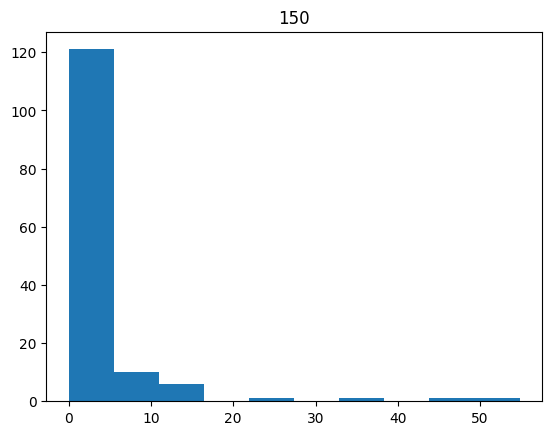

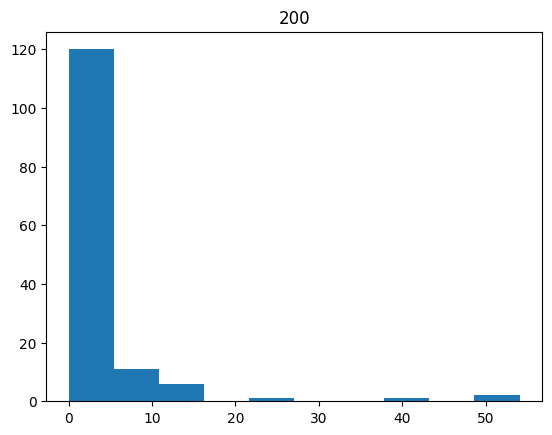

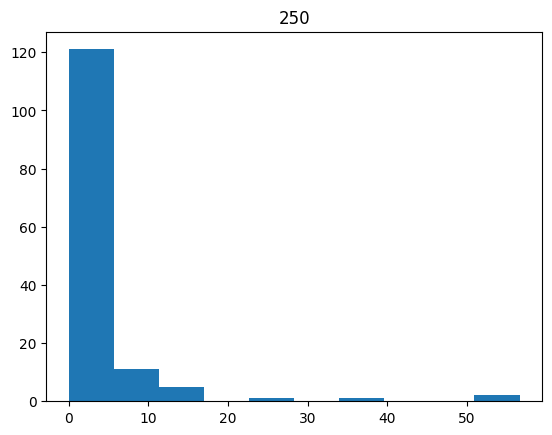

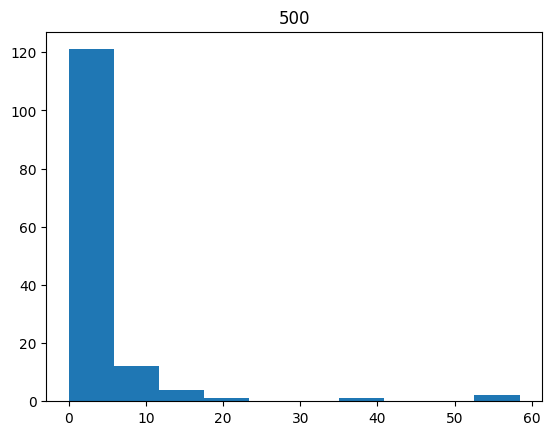

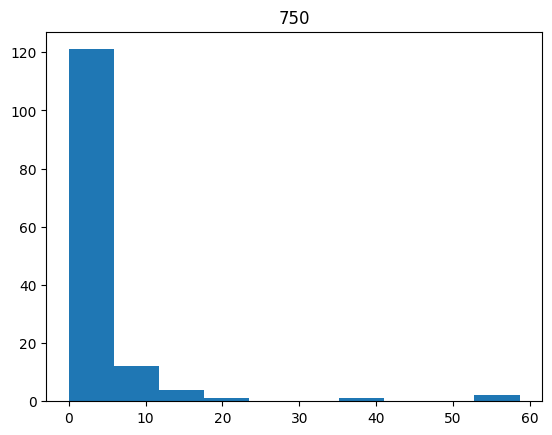

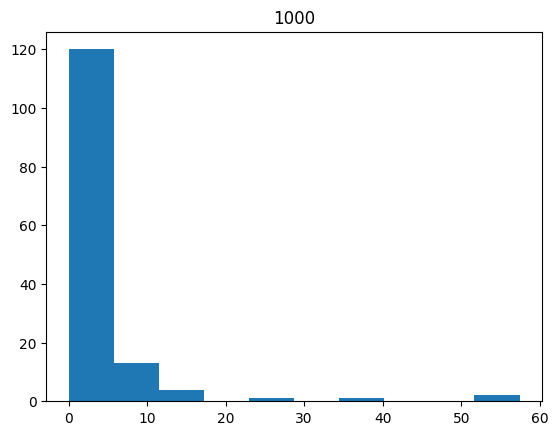

In [44]:
import matplotlib.pyplot as plt

n_trees = [25,50,100,150,200,250,500,750,1000]
for n in n_trees:
  forest = RandomForestRegressor(n_estimators = n, random_state = 50)
  forest.fit(x_train, y_train)
  predictions = forest.predict(x_test)
  score = mean_squared_error(y_test, predictions)
  print(n, score)
  errors = [0] *len(y_test)
  for i in range(len(y_test)):
    errors[i] = (y_test.iloc[i]-predictions[i])**2
    if errors[i] > 10:
      print("Loss of index: ",i,"is:", errors[i])
  plt.figure()
  plt.hist(errors)
  plt.title(n)
